New names:
• `` -> `...1`
Rows: 1711601 Columns: 23
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (1): Class
dbl  (5): ...1, X, Y, Allsubtypes, neighborhood10
lgl (17): 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


cutree(p$tree_row, k = 17)
 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 
 3 12 10  6  9  6  5  4  6  2  1 20 12  6  1  2  1 

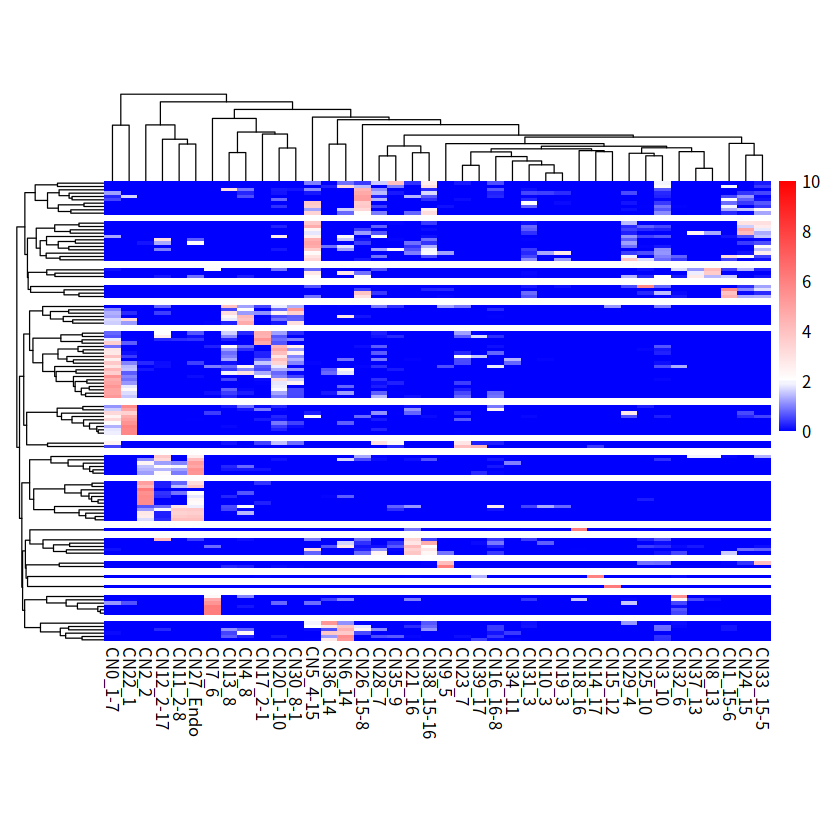

In [46]:
##### R 3.6.3

library(tidyverse) #v1.3.0
library(tidyr)  #v1.1.4
library(Rphenograph)  #v0.99.1
library(ggpubr)   #v0.4.0
library(ggthemes) #v4.2.0
library(Rtsne)  #v0.15
library(flowCore)   #v1.52.1
library(Rcpp)  #v1.0.5
library(igraph) #v1.2.6
library(survival)   #v3.2.7
library(survminer)  #v0.4.8
library(pheatmap)  #v1.0.12
library(ggsci)  #v2.9



# Fig.3A TP heatmap------------------------------------------------------


gc_csd_CN <- read_csv(file = '/home/qyyuan/project/Lifei-Spatial/analysis/Part_2_discovery_cohort_CN_definition/cells_r=50_CN=40.csv')
gc_csd_CN_anno <- gc_csd_CN %>% mutate(All_CN=paste0('CN',neighborhood10))
gc_csd_CN_anno$All_CN[gc_csd_CN_anno$All_CN=='CN1'] <- 'CN1_15-6'
gc_csd_CN_anno$All_CN[gc_csd_CN_anno$All_CN=='CN2'] <- 'CN2_2'
gc_csd_CN_anno$All_CN[gc_csd_CN_anno$All_CN=='CN3'] <- 'CN3_10'
gc_csd_CN_anno$All_CN[gc_csd_CN_anno$All_CN=='CN4'] <- 'CN4_8'
gc_csd_CN_anno$All_CN[gc_csd_CN_anno$All_CN=='CN5'] <- 'CN5_4-15'
gc_csd_CN_anno$All_CN[gc_csd_CN_anno$All_CN=='CN6'] <- 'CN6_14'
gc_csd_CN_anno$All_CN[gc_csd_CN_anno$All_CN=='CN7'] <- 'CN7_6'
gc_csd_CN_anno$All_CN[gc_csd_CN_anno$All_CN=='CN8'] <- 'CN8_13'
gc_csd_CN_anno$All_CN[gc_csd_CN_anno$All_CN=='CN9'] <- 'CN9_5'
gc_csd_CN_anno$All_CN[gc_csd_CN_anno$All_CN=='CN10'] <- 'CN10_3'
gc_csd_CN_anno$All_CN[gc_csd_CN_anno$All_CN=='CN11'] <- 'CN11_2-8'
gc_csd_CN_anno$All_CN[gc_csd_CN_anno$All_CN=='CN12'] <- 'CN12_2-17'
gc_csd_CN_anno$All_CN[gc_csd_CN_anno$All_CN=='CN13'] <- 'CN13_8'
gc_csd_CN_anno$All_CN[gc_csd_CN_anno$All_CN=='CN14'] <- 'CN14_17'
gc_csd_CN_anno$All_CN[gc_csd_CN_anno$All_CN=='CN15'] <- 'CN15_12'
gc_csd_CN_anno$All_CN[gc_csd_CN_anno$All_CN=='CN16'] <- 'CN16_16-8'
gc_csd_CN_anno$All_CN[gc_csd_CN_anno$All_CN=='CN17'] <- 'CN17_2-1'
gc_csd_CN_anno$All_CN[gc_csd_CN_anno$All_CN=='CN18'] <- 'CN18_16'
gc_csd_CN_anno$All_CN[gc_csd_CN_anno$All_CN=='CN19'] <- 'CN19_3'
gc_csd_CN_anno$All_CN[gc_csd_CN_anno$All_CN=='CN20'] <- 'CN20_1-10'
gc_csd_CN_anno$All_CN[gc_csd_CN_anno$All_CN=='CN21'] <- 'CN21_16'
gc_csd_CN_anno$All_CN[gc_csd_CN_anno$All_CN=='CN22'] <- 'CN22_1'
gc_csd_CN_anno$All_CN[gc_csd_CN_anno$All_CN=='CN23'] <- 'CN23_7'
gc_csd_CN_anno$All_CN[gc_csd_CN_anno$All_CN=='CN24'] <- 'CN24_15'
gc_csd_CN_anno$All_CN[gc_csd_CN_anno$All_CN=='CN25'] <- 'CN25_10'
gc_csd_CN_anno$All_CN[gc_csd_CN_anno$All_CN=='CN26'] <- 'CN26_15-8'
gc_csd_CN_anno$All_CN[gc_csd_CN_anno$All_CN=='CN27'] <- 'CN27_Endo'
gc_csd_CN_anno$All_CN[gc_csd_CN_anno$All_CN=='CN28'] <- 'CN28_7'
gc_csd_CN_anno$All_CN[gc_csd_CN_anno$All_CN=='CN29'] <- 'CN29_4'
gc_csd_CN_anno$All_CN[gc_csd_CN_anno$All_CN=='CN30'] <- 'CN30_8-1'
gc_csd_CN_anno$All_CN[gc_csd_CN_anno$All_CN=='CN31'] <- 'CN31_3'
gc_csd_CN_anno$All_CN[gc_csd_CN_anno$All_CN=='CN32'] <- 'CN32_6'
gc_csd_CN_anno$All_CN[gc_csd_CN_anno$All_CN=='CN33'] <- 'CN33_15-5'
gc_csd_CN_anno$All_CN[gc_csd_CN_anno$All_CN=='CN34'] <- 'CN34_11'
gc_csd_CN_anno$All_CN[gc_csd_CN_anno$All_CN=='CN35'] <- 'CN35_9'
gc_csd_CN_anno$All_CN[gc_csd_CN_anno$All_CN=='CN36'] <- 'CN36_14'
gc_csd_CN_anno$All_CN[gc_csd_CN_anno$All_CN=='CN37'] <- 'CN37_13'
gc_csd_CN_anno$All_CN[gc_csd_CN_anno$All_CN=='CN38'] <- 'CN38_15-16' #HII, High Immune Infiltrate
gc_csd_CN_anno$All_CN[gc_csd_CN_anno$All_CN=='CN39'] <- 'CN39_17'
gc_csd_CN_anno$All_CN[gc_csd_CN_anno$All_CN=='CN0'] <- 'CN0_1-7'

cells_CN <- gc_csd_CN_anno %>% dplyr::select(Class, All_CN)
dat <- as.data.frame(with(cells_CN, table(Class, All_CN)))
cells_CN_Freq <- spread(dat, All_CN, Freq)

dat_CN_freq <- cells_CN_Freq[,-1]
row.names(dat_CN_freq) <- cells_CN_Freq$Class

dat_CN_percent <- dat_CN_freq / rowSums(dat_CN_freq) * 100
row.names(dat_CN_percent)<- cells_CN_Freq$Class

bk <- c(seq(0,1.9,by=0.01),seq(2,10,by=0.01))
p <- pheatmap(dat_CN_percent,
              cellwidth = 10,
              cellheight = 2,
              # annotation_row = df_TP,
              border=FALSE,
              color=c(colorRampPalette(colors=c("blue","white"))(length(bk)/5),colorRampPalette(color=c("white","red"))(length(bk)*4/5)),
              scale = 'row',
              cluster_rows = T,
              show_rownames = F,
              show_colnames = T,
              legend_breaks=seq(0,10,2),
              breaks=bk,
              cutree_rows = 17)

row_cluster <- as.data.frame(cutree(p$tree_row,k=17))
table(row_cluster)
names(row_cluster) <- 'PhenoGraph'
row_cluster$Class <-  row.names(row_cluster)

dat_CN_percent_class <- dat_CN_percent
dat_CN_percent_class$Class <- row.names(dat_CN_percent)

df_merge <- merge(row_cluster,dat_CN_percent_class,by='Class')

df_merge <- df_merge[order(df_merge$PhenoGraph),]
temp <- df_merge[,c(-1,-2)]
row.names(temp) <- df_merge$Class 

anno <- df_merge[2]
row.names(anno) <- df_merge$Class
anno$PhenoGraph <- as.factor(anno$PhenoGraph)

row_cluster$Cluster <- row_cluster$PhenoGraph

row_cluster$Cluster[row_cluster$Cluster== 1] <- 'TP_1'
row_cluster$Cluster[row_cluster$Cluster== 2] <- 'TP_2'
row_cluster$Cluster[row_cluster$Cluster== 3] <- 'TP_3'
row_cluster$Cluster[row_cluster$Cluster== 4] <- 'TP_4-13'
row_cluster$Cluster[row_cluster$Cluster== 5] <- 'TP_5'
row_cluster$Cluster[row_cluster$Cluster== 6] <- 'TP_6'
row_cluster$Cluster[row_cluster$Cluster== 7] <- 'TP_7'
row_cluster$Cluster[row_cluster$Cluster== 8] <- 'TP_8'
row_cluster$Cluster[row_cluster$Cluster== 9] <- 'TP_9'
row_cluster$Cluster[row_cluster$Cluster== 10] <- 'TP_10'
row_cluster$Cluster[row_cluster$Cluster== 11] <- 'TP_11'
row_cluster$Cluster[row_cluster$Cluster== 12] <- 'TP_12'
row_cluster$Cluster[row_cluster$Cluster== 13] <- 'TP_4-13'
row_cluster$Cluster[row_cluster$Cluster== 14] <- 'TP_14'
row_cluster$Cluster[row_cluster$Cluster== 15] <- 'TP_15'
row_cluster$Cluster[row_cluster$Cluster== 16] <- 'TP_16'
row_cluster$Cluster[row_cluster$Cluster== 17] <- 'TP_17'

dat_CN_percent_class <- dat_CN_percent
dat_CN_percent_class$Class <- row.names(dat_CN_percent)

df_merge <- merge(row_cluster,dat_CN_percent_class,by='Class')

temp <- df_merge[,c(-1,-2,-3)]
row.names(temp) <- df_merge$Class 

anno <- df_merge[3]
row.names(anno) <- df_merge$Class

anno$Class = rownames(anno)
#anno_add <- readRDS("Class_Pheno_Anno_ctCN.Rds")
anno_add=read.table('mydata_pheno02.csv', sep=',', header = TRUE, row.names = 1)


In [31]:
anno

,Cluster,Class
,<chr>,<chr>
mADT-1.tsv,TP_1,mADT-1.tsv
mADT-10.tsv,TP_2,mADT-10.tsv
mADT-11.tsv,TP_3,mADT-11.tsv
mADT-12.tsv,TP_3,mADT-12.tsv
mADT-13.tsv,TP_3,mADT-13.tsv
mADT-14.tsv,TP_4-13,mADT-14.tsv
mADT-15.tsv,TP_5,mADT-15.tsv
mADT-16.tsv,TP_2,mADT-16.tsv
mADT-17.tsv,TP_3,mADT-17.tsv


In [32]:
anno_add

,Class,TumorPurityLevel,CN0_1,CN1_13.3,CN2_2,CN3_12,CN4_6,CN5_8,CN6_4,CN7_14,CN8_15.5,CN9_2,Class0
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
mADT-1.tsv,mADT-1.tsv,L,4.765333508,34.13628330,1.688813249,0.79858611,1.210970740,5.49846174,20.6585063,16.20082477,15.04222,0.0000000,mADT-1.tsv
mADT-10.tsv,mADT-10.tsv,L,0.000000000,1.82328191,1.309022908,1.91678354,0.040072130,1.52274093,33.4535497,0.00000000,59.93455,0.0000000,mADT-10.tsv
mADT-11.tsv,mADT-11.tsv,L,0.204304004,5.50258785,0.000000000,0.17706347,0.490329610,10.88259330,33.7101607,0.00000000,49.03296,0.0000000,mADT-11.tsv
mADT-12.tsv,mADT-12.tsv,L,2.378255946,2.08380521,0.000000000,0.11325028,0.532276331,14.51868630,28.3352208,0.24915062,51.78935,0.0000000,mADT-12.tsv
mADT-13.tsv,mADT-16.tsv,L,2.484523318,1.89847297,0.000000000,5.77796121,4.308708213,1.98926950,28.3945522,0.00000000,55.14651,0.0000000,mADT-13.tsv
mADT-14.tsv,mADT-17.tsv,L,0.057890471,0.12156999,2.442977886,3.09135116,0.063679518,6.43163135,13.6910964,10.44923006,63.45375,0.1968276,mADT-14.tsv
mADT-15.tsv,mADT-2.tsv,L,4.891475307,22.41270840,0.007864108,1.41553948,2.917584146,4.49826990,17.8122051,3.12991507,42.91444,0.0000000,mADT-15.tsv
mADT-16.tsv,mADT-21.tsv,L,21.826374287,0.21628117,0.793030940,8.58516071,0.030039051,0.62481226,21.4058276,11.67317513,34.84530,0.0000000,mADT-16.tsv
mADT-17.tsv,mADT-22.tsv,L,0.006374299,0.85415604,0.000000000,10.01402346,0.631055584,0.12111168,37.8824579,18.68944416,31.80138,0.0000000,mADT-17.tsv


In [47]:
#anno_add =anno
anno_add = merge(anno,anno_add,by="Class")
rownames(anno_add) = anno_add$Class

In [48]:
n_rows <- nrow(anno_add)

# 生成随机整数：0 或 1 (概率各 50%)
# sample(x, size, replace = TRUE)
anno_add$LiverCirrhosis <- sample(c("0", "1"), size = n_rows, replace = TRUE)
anno_add$Caspsule <- sample(c("0", "1"), size = n_rows, replace = TRUE)
anno_add$BileDuctThrombi <- sample(c("0", "1"), size = n_rows, replace = TRUE)

In [28]:
anno

,Cluster,Class
,<chr>,<chr>
mADT-1.tsv,TP_1,mADT-1.tsv
mADT-10.tsv,TP_2,mADT-10.tsv
mADT-11.tsv,TP_3,mADT-11.tsv
mADT-12.tsv,TP_3,mADT-12.tsv
mADT-13.tsv,TP_3,mADT-13.tsv
mADT-14.tsv,TP_4-13,mADT-14.tsv
mADT-15.tsv,TP_5,mADT-15.tsv
mADT-16.tsv,TP_2,mADT-16.tsv
mADT-17.tsv,TP_3,mADT-17.tsv


In [35]:
anno_add = subset(anno_add,select = c("Cluster","TumorPurityLevel","LiverCirrhosis","Caspsule","BileDuctThrombi"))


       TP_1        TP_2        TP_3     TP_4-13        TP_5        TP_6 
"#1F77B4FF" "#FF7F0EFF" "#2CA02CFF" "#D62728FF" "#9467BDFF" "#8C564BFF" 
       TP_7        TP_8        TP_9       TP_10       TP_11       TP_12 
"#E377C2FF" "#7F7F7FFF" "#BCBD22FF" "#17BECFFF" "#AEC7E8FF" "#FFBB78FF" 
      TP_14       TP_15       TP_16       TP_17 
"#98DF8AFF" "#FF9896FF" "#C5B0D5FF" "#C49C94FF" 


pdf 
  2

ERROR: Error in CrossTable(anno_add$`Tumor Pattern`, anno_add$`Bile Duct Thrombi`, : 没有"CrossTable"这个函数


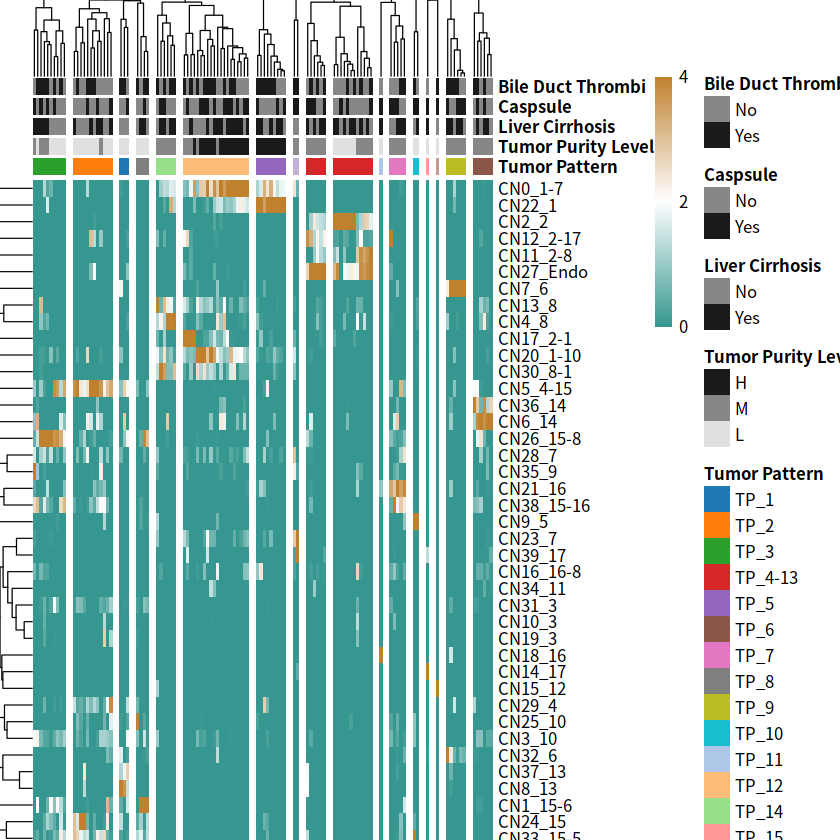

In [49]:

anno_add = subset(anno_add,select = c("Cluster","TumorPurityLevel","LiverCirrhosis","Caspsule","BileDuctThrombi"))
colnames(anno_add) = c("Tumor Pattern","Tumor Purity Level","Liver Cirrhosis","Caspsule","Bile Duct Thrombi")
anno_add$`Liver Cirrhosis` = as.factor(anno_add$`Liver Cirrhosis`)
anno_add$Caspsule = as.factor(anno_add$Caspsule)
anno_add$`Bile Duct Thrombi` = as.factor(anno_add$`Bile Duct Thrombi`)
anno_add$`Tumor Purity Level` = factor(anno_add$`Tumor Purity Level`, levels = c("L","M","H"))

anno_add$`Liver Cirrhosis` = ifelse(anno_add$`Liver Cirrhosis` == 0, "No", "Yes")
anno_add$Caspsule = ifelse(anno_add$Caspsule == 1, "Yes", "No")
anno_add$Caspsule = ifelse(is.na(anno_add$Caspsule), "No", anno_add$Caspsule)
anno_add$`Bile Duct Thrombi` = ifelse(anno_add$`Bile Duct Thrombi` == 0, "No", "Yes")

# anno_colors = list(
#   'Tumor Pattern' = c(TP_Others = pal_d3("category20")(14)[1],
#                       TP_p_mTOR = pal_d3("category20")(14)[2],
#                       TP_Hepar1 = pal_d3("category20")(14)[3],
#                       TP_Ki67 = pal_d3("category20")(14)[4],
#                       TP_CD107a = pal_d3("category20")(14)[5],
#                       TP_p_S6 = pal_d3("category20")(14)[6],
#                       TP_E_cadherin = pal_d3("category20")(14)[7],
#                       TP_Glypican3 = pal_d3("category20")(14)[8],
#                       TP_c_Myc = pal_d3("category20")(14)[9],
#                       TP_CN22 = pal_d3("category20")(14)[10],
#                       TP_ImmuneMix = pal_d3("category20")(14)[11],
#                       TP13 = pal_d3("category20")(14)[12],
#                       TP_p53 = pal_d3("category20")(14)[13],
#                       TP_Twist1 = pal_d3("category20")(14)[14]),
#   'Caspsule' = c('No' = "#878787", 'Yes' = "#1a1a1a"),
#   'Liver Cirrhosis' = c('No' = "#878787", 'Yes' = "#1a1a1a"),
#   'Bile Duct Thrombi' = c('No' = "#878787", 'Yes' = "#1a1a1a"),
#   'Tumor Purity Level' = c(H = "#1a1a1a", M = "#878787", L = "#e0e0e0")
# )




library(dichromat) # 或者你之前用的包，确保 pal_d3 可用
# 如果没有加载包，请先 library(RColorBrewer) 或定义 pal_d3

# 1. 定义你的新聚类名称列表 (按你想要的顺序排列)
# 注意：字符排序时 "TP_10" 会排在 "TP_2" 前面，如果需要数字逻辑排序，建议手动列出
new_cluster_names <- c(
  "TP_1", "TP_2", "TP_3", "TP_4-13", "TP_5", "TP_6", "TP_7", 
  "TP_8", "TP_9", "TP_10", "TP_11", "TP_12", "TP_14", "TP_15", 
  "TP_16", "TP_17"
)
# 检查是否漏掉了任何名称，或者顺序是否需要调整
# length(new_cluster_names) 应该是 16 (因为 4 和 13 合并了)

# 2. 生成对应数量的颜色
n_colors <- length(new_cluster_names)
# 使用 dichromat 或其他调色板生成 n_colors 个颜色
# 这里假设 pal_d3("category20") 能生成足够多的颜色，如果不够可以用 category20x
my_colors <- pal_d3("category20")(max(20, n_colors))[1:n_colors]

# 3. 创建命名向量
cluster_color_map <- setNames(my_colors, new_cluster_names)

# 4. 更新 anno_colors
anno_colors = list(
  'Tumor Pattern' = cluster_color_map, # 直接使用新生成的映射
  
  # 其他列保持不变
  'Caspsule' = c('No' = "#878787", 'Yes' = "#1a1a1a"),
  'Liver Cirrhosis' = c('No' = "#878787", 'Yes' = "#1a1a1a"),
  'Bile Duct Thrombi' = c('No' = "#878787", 'Yes' = "#1a1a1a"),
  'Tumor Purity Level' = c(H = "#1a1a1a", M = "#878787", L = "#e0e0e0")
)

# 验证一下
print(anno_colors[['Tumor Pattern']])



bk <- c(seq(0,2,by=0.01),seq(2.01,4,by=0.01))
temp = t(temp)
p <- pheatmap(temp,
              cellwidth = 2,
              cellheight = 10,
              annotation_col = anno_add,
              annotation_colors = anno_colors,
              border=FALSE,
              color=c(colorRampPalette(colors=c("#35978f","white"))(length(bk)/2),colorRampPalette(color=c("white","#bf812d"))(length(bk)/2)),
              scale = 'column',
              cluster_rows = T,
              cluster_cols = T,
              show_rownames = T,
              show_colnames = F,
              legend_breaks=seq(0,4,2),
              breaks=bk,
              cutree_cols = 17)

pdf(file = "TP_heatmap.pdf", width =20, height = 10)
print(p)
dev.off()

CrossTable(anno_add$`Tumor Pattern`, anno_add$`Bile Duct Thrombi`, fisher=T, chisq =T, format="SPSS",
           prop.c = T,prop.t = T,prop.chisq = T,expected=T)




In [51]:
library(gmodels)
CrossTable(anno_add$`Tumor Pattern`, anno_add$`Bile Duct Thrombi`, fisher=T, chisq =T, format="SPSS",
           prop.c = T,prop.t = T,prop.chisq = T,expected=T)


Warning message in chisq.test(t, correct = FALSE, ...):
“Chi-squared近似算法有可能不准”



   Cell Contents
|-------------------------|
|                   Count |
|         Expected Values |
| Chi-square contribution |
|             Row Percent |
|          Column Percent |
|           Total Percent |
|-------------------------|

Total Observations in Table:  106 

                         | anno_add$`Bile Duct Thrombi` 
anno_add$`Tumor Pattern` |       No  |      Yes  | Row Total | 
-------------------------|-----------|-----------|-----------|
                    TP_1 |        1  |        2  |        3  | 
                         |    1.443  |    1.557  |           | 
                         |    0.136  |    0.126  |           | 
                         |   33.333% |   66.667% |    2.830% | 
                         |    1.961% |    3.636% |           | 
                         |    0.943% |    1.887% |           | 
-------------------------|-----------|-----------|-----------|
                   TP_10 |        1  |        1  |        2  | 
                         |

In [45]:
anno_colors

$`Tumor Pattern`
    TP_Others     TP_p_mTOR     TP_Hepar1       TP_Ki67     TP_CD107a 
  "#1F77B4FF"   "#FF7F0EFF"   "#2CA02CFF"   "#D62728FF"   "#9467BDFF" 
      TP_p_S6 TP_E_cadherin  TP_Glypican3      TP_c_Myc       TP_CN22 
  "#8C564BFF"   "#E377C2FF"   "#7F7F7FFF"   "#BCBD22FF"   "#17BECFFF" 
 TP_ImmuneMix          TP13        TP_p53     TP_Twist1 
  "#AEC7E8FF"   "#FFBB78FF"   "#98DF8AFF"   "#FF9896FF" 

$Caspsule
       No       Yes 
"#878787" "#1a1a1a" 

$`Liver Cirrhosis`
       No       Yes 
"#878787" "#1a1a1a" 

$`Bile Duct Thrombi`
       No       Yes 
"#878787" "#1a1a1a" 

$`Tumor Purity Level`
        H         M         L 
"#1a1a1a" "#878787" "#e0e0e0"

In [38]:
temp

,mADT-1.tsv,mADT-10.tsv,mADT-11.tsv,mADT-12.tsv,mADT-13.tsv,mADT-14.tsv,mADT-15.tsv,mADT-16.tsv,mADT-17.tsv,mADT-19.tsv,⋯,N-51.tsv,N-52.tsv,N-53.tsv,N-54.tsv,N-55.tsv,N-56.tsv,N-6.tsv,N-7.tsv,N-8.tsv,N-9.tsv
CN0_1-7,1.81972900,0.000000000,0.00000000,0.23782559,7.283346217,1.770442611,20.022253129,0.28064383,0.005789047,19.4483240,⋯,32.758798638,10.890963358,15.066964286,30.620239391,1.29826450,0.012317293,0.005337603,0.40180565,0.000000000,0.00000000
CN1_15-6,2.67722720,0.500901623,7.43666576,12.25368063,0.240487847,0.660165041,0.267037552,15.77383409,8.475164988,0.8554469,⋯,0.010320983,0.336572045,0.000000000,0.005440696,0.00000000,0.036951880,0.005337603,0.00000000,0.000000000,0.01688999
CN10_3,0.09164103,0.561009818,0.24516481,0.14722537,4.388903204,0.150037509,0.250347705,1.45274453,0.075257613,0.0000000,⋯,0.000000000,0.000000000,0.000000000,0.016322089,0.00000000,0.004105764,0.000000000,0.00000000,7.780013414,0.77130954
CN11_2-8,0.01963736,0.000000000,0.00000000,0.00000000,0.000000000,2.393098275,0.000000000,0.00000000,0.214194744,0.0000000,⋯,0.005160491,0.114307487,4.886798469,0.027203482,0.46414637,0.000000000,14.827862290,26.40011905,13.890006707,14.77311114
CN12_2-17,1.37461543,1.322380285,0.00000000,0.00000000,0.000000000,16.924231058,0.000000000,0.00000000,1.852495079,0.0000000,⋯,0.485086180,1.409792341,4.480229592,1.517954298,1.81622494,0.000000000,16.535895383,4.20655786,5.694164990,4.42517734
CN13_8,1.09969235,0.000000000,0.09534187,1.63080408,1.649059521,1.890472618,0.995827538,0.22286422,0.138937131,0.0000000,⋯,4.030343689,1.917825618,4.225127551,0.233949946,5.71774519,0.032846116,4.424873232,2.60429585,4.795439302,0.90642946
CN14_17,0.00000000,0.000000000,0.00000000,0.00000000,0.000000000,0.000000000,0.000000000,0.00000000,0.000000000,0.0000000,⋯,0.165135721,0.076204991,0.000000000,0.000000000,0.03363380,0.000000000,0.037363224,0.00000000,0.000000000,0.00000000
CN15_12,0.00000000,0.000000000,0.00000000,0.00000000,0.000000000,0.000000000,0.000000000,0.00000000,0.000000000,0.0000000,⋯,0.000000000,1.339937766,0.000000000,0.000000000,0.00000000,97.438002956,0.000000000,0.00000000,0.000000000,0.00000000
CN16_16-8,0.41893042,0.000000000,0.08172160,0.05662514,3.478484927,3.278319580,2.314325452,1.04828725,0.521014241,0.0000000,⋯,7.596243162,14.815520417,0.374681122,0.000000000,1.54715458,0.016423058,3.624232720,1.35423384,13.038229376,0.35468979
CN17_2-1,0.71349087,0.160288519,0.00000000,0.00000000,0.000000000,1.447861965,0.000000000,0.00000000,0.000000000,0.0000000,⋯,0.866962535,7.423636248,40.027104592,39.853101197,1.59424189,0.000000000,0.192153723,1.32447046,0.020120724,0.05066997


In [39]:
anno_add

,Tumor Pattern,Tumor Purity Level,Liver Cirrhosis,Caspsule,Bile Duct Thrombi
,<chr>,<fct>,<chr>,<chr>,<chr>
mADT-1.tsv,TP_1,L,No,No,Yes
mADT-10.tsv,TP_2,L,Yes,No,Yes
mADT-11.tsv,TP_3,L,No,No,Yes
mADT-12.tsv,TP_3,L,Yes,Yes,Yes
mADT-13.tsv,TP_3,M,No,Yes,Yes
mADT-14.tsv,TP_4-13,M,Yes,No,No
mADT-15.tsv,TP_5,H,Yes,Yes,Yes
mADT-16.tsv,TP_2,L,No,Yes,No
mADT-17.tsv,TP_3,L,No,No,No


In [40]:
anno_colors

$`Tumor Pattern`
    TP_Others     TP_p_mTOR     TP_Hepar1       TP_Ki67     TP_CD107a 
  "#1F77B4FF"   "#FF7F0EFF"   "#2CA02CFF"   "#D62728FF"   "#9467BDFF" 
      TP_p_S6 TP_E_cadherin  TP_Glypican3      TP_c_Myc       TP_CN22 
  "#8C564BFF"   "#E377C2FF"   "#7F7F7FFF"   "#BCBD22FF"   "#17BECFFF" 
 TP_ImmuneMix          TP13        TP_p53     TP_Twist1 
  "#AEC7E8FF"   "#FFBB78FF"   "#98DF8AFF"   "#FF9896FF" 

$Caspsule
       No       Yes 
"#878787" "#1a1a1a" 

$`Liver Cirrhosis`
       No       Yes 
"#878787" "#1a1a1a" 

$`Bile Duct Thrombi`
       No       Yes 
"#878787" "#1a1a1a" 

$`Tumor Purity Level`
        H         M         L 
"#1a1a1a" "#878787" "#e0e0e0"

In [41]:
p <- pheatmap(temp,
              cellwidth = 2,
              cellheight = 10,
              annotation_col = anno_add[,1:2],
              annotation_colors = anno_colors,
              border=FALSE,
              color=c(colorRampPalette(colors=c("#35978f","white"))(length(bk)/2),colorRampPalette(color=c("white","#bf812d"))(length(bk)/2)),
              scale = 'column',
              cluster_rows = T,
              cluster_cols = T,
              show_rownames = T,
              show_colnames = F,
              legend_breaks=seq(0,4,2),
              breaks=bk,
              cutree_cols = 17)

pdf(file = "TP_heatmap.pdf", width =20, height = 10)
print(p)
dev.off()

CrossTable(anno_add$`Tumor Pattern`, anno_add$`Bile Duct Thrombi`, fisher=T, chisq =T, format="SPSS",
           prop.c = T,prop.t = T,prop.chisq = T,expected=T)


ERROR: Error in convert_annotations(annotation_col, annotation_colors): Factor levels on variable Tumor Pattern do not match with annotation_colors


In [6]:
anno_add

,Class,Cluster.x,Cluster.y
,<chr>,<chr>,<chr>
mADT-1.tsv,mADT-1.tsv,TP_1,TP_1
mADT-10.tsv,mADT-10.tsv,TP_2,TP_2
mADT-11.tsv,mADT-11.tsv,TP_3,TP_3
mADT-12.tsv,mADT-12.tsv,TP_3,TP_3
mADT-13.tsv,mADT-13.tsv,TP_3,TP_3
mADT-14.tsv,mADT-14.tsv,TP_4-13,TP_4-13
mADT-15.tsv,mADT-15.tsv,TP_5,TP_5
mADT-16.tsv,mADT-16.tsv,TP_2,TP_2
mADT-17.tsv,mADT-17.tsv,TP_3,TP_3


New names:
• `` -> `...1`
Rows: 1711601 Columns: 23
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (1): Class
dbl  (5): ...1, X, Y, Allsubtypes, neighborhood10
lgl (17): 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


cutree(p$tree_row, k = 17)
 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 
 3 12 10  6  9  6  5  4  6  2  1 20 12  6  1  2  1 

Warning message in gzfile(file, "rb"):
“无法打开压缩文件'Class_Pheno_Anno_ctCN.Rds'，可能是因为'没有那个文件或目录'”


ERROR: Error in gzfile(file, "rb"): 无法打开链结


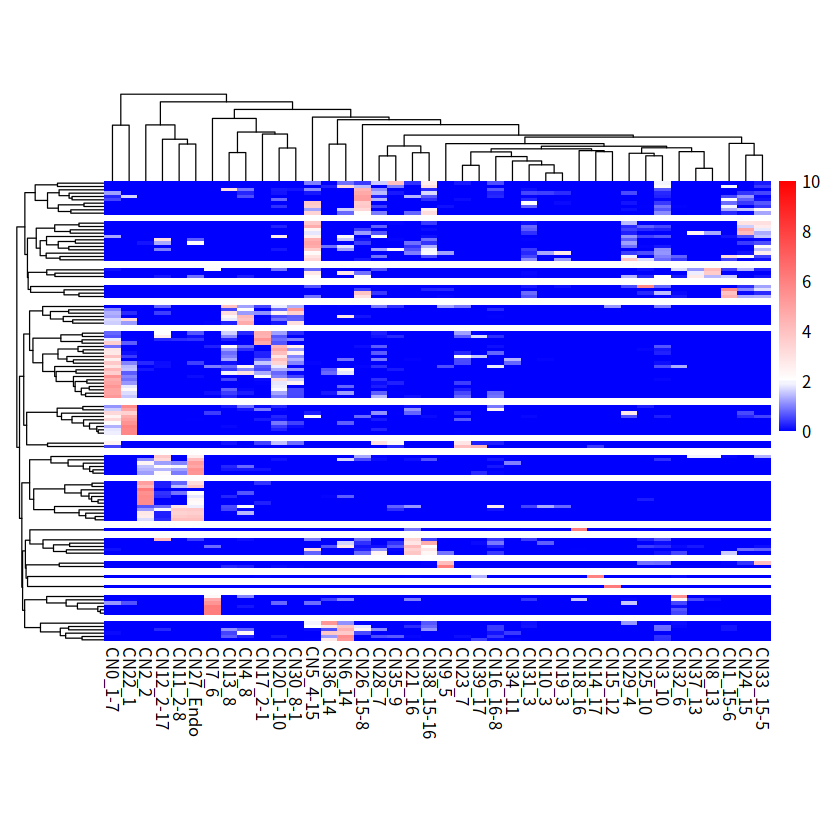

In [53]:


##### R 3.6.3

library(tidyverse) #v1.3.0
library(tidyr)  #v1.1.4
library(Rphenograph)  #v0.99.1
library(ggpubr)   #v0.4.0
library(ggthemes) #v4.2.0
library(Rtsne)  #v0.15
library(flowCore)   #v1.52.1
library(Rcpp)  #v1.0.5
library(igraph) #v1.2.6
library(survival)   #v3.2.7
library(survminer)  #v0.4.8
library(pheatmap)  #v1.0.12
library(ggsci)  #v2.9



# Fig.3A TP heatmap------------------------------------------------------


gc_csd_CN <- read_csv(file = '/home/qyyuan/project/Lifei-Spatial/analysis/Part_2_discovery_cohort_CN_definition/cells_r=50_CN=40.csv')
gc_csd_CN_anno <- gc_csd_CN %>% mutate(All_CN=paste0('CN',neighborhood10))
gc_csd_CN_anno$All_CN[gc_csd_CN_anno$All_CN=='CN1'] <- 'CN1_15-6'
gc_csd_CN_anno$All_CN[gc_csd_CN_anno$All_CN=='CN2'] <- 'CN2_2'
gc_csd_CN_anno$All_CN[gc_csd_CN_anno$All_CN=='CN3'] <- 'CN3_10'
gc_csd_CN_anno$All_CN[gc_csd_CN_anno$All_CN=='CN4'] <- 'CN4_8'
gc_csd_CN_anno$All_CN[gc_csd_CN_anno$All_CN=='CN5'] <- 'CN5_4-15'
gc_csd_CN_anno$All_CN[gc_csd_CN_anno$All_CN=='CN6'] <- 'CN6_14'
gc_csd_CN_anno$All_CN[gc_csd_CN_anno$All_CN=='CN7'] <- 'CN7_6'
gc_csd_CN_anno$All_CN[gc_csd_CN_anno$All_CN=='CN8'] <- 'CN8_13'
gc_csd_CN_anno$All_CN[gc_csd_CN_anno$All_CN=='CN9'] <- 'CN9_5'
gc_csd_CN_anno$All_CN[gc_csd_CN_anno$All_CN=='CN10'] <- 'CN10_3'
gc_csd_CN_anno$All_CN[gc_csd_CN_anno$All_CN=='CN11'] <- 'CN11_2-8'
gc_csd_CN_anno$All_CN[gc_csd_CN_anno$All_CN=='CN12'] <- 'CN12_2-17'
gc_csd_CN_anno$All_CN[gc_csd_CN_anno$All_CN=='CN13'] <- 'CN13_8'
gc_csd_CN_anno$All_CN[gc_csd_CN_anno$All_CN=='CN14'] <- 'CN14_17'
gc_csd_CN_anno$All_CN[gc_csd_CN_anno$All_CN=='CN15'] <- 'CN15_12'
gc_csd_CN_anno$All_CN[gc_csd_CN_anno$All_CN=='CN16'] <- 'CN16_16-8'
gc_csd_CN_anno$All_CN[gc_csd_CN_anno$All_CN=='CN17'] <- 'CN17_2-1'
gc_csd_CN_anno$All_CN[gc_csd_CN_anno$All_CN=='CN18'] <- 'CN18_16'
gc_csd_CN_anno$All_CN[gc_csd_CN_anno$All_CN=='CN19'] <- 'CN19_3'
gc_csd_CN_anno$All_CN[gc_csd_CN_anno$All_CN=='CN20'] <- 'CN20_1-10'
gc_csd_CN_anno$All_CN[gc_csd_CN_anno$All_CN=='CN21'] <- 'CN21_16'
gc_csd_CN_anno$All_CN[gc_csd_CN_anno$All_CN=='CN22'] <- 'CN22_1'
gc_csd_CN_anno$All_CN[gc_csd_CN_anno$All_CN=='CN23'] <- 'CN23_7'
gc_csd_CN_anno$All_CN[gc_csd_CN_anno$All_CN=='CN24'] <- 'CN24_15'
gc_csd_CN_anno$All_CN[gc_csd_CN_anno$All_CN=='CN25'] <- 'CN25_10'
gc_csd_CN_anno$All_CN[gc_csd_CN_anno$All_CN=='CN26'] <- 'CN26_15-8'
gc_csd_CN_anno$All_CN[gc_csd_CN_anno$All_CN=='CN27'] <- 'CN27_Endo'
gc_csd_CN_anno$All_CN[gc_csd_CN_anno$All_CN=='CN28'] <- 'CN28_7'
gc_csd_CN_anno$All_CN[gc_csd_CN_anno$All_CN=='CN29'] <- 'CN29_4'
gc_csd_CN_anno$All_CN[gc_csd_CN_anno$All_CN=='CN30'] <- 'CN30_8-1'
gc_csd_CN_anno$All_CN[gc_csd_CN_anno$All_CN=='CN31'] <- 'CN31_3'
gc_csd_CN_anno$All_CN[gc_csd_CN_anno$All_CN=='CN32'] <- 'CN32_6'
gc_csd_CN_anno$All_CN[gc_csd_CN_anno$All_CN=='CN33'] <- 'CN33_15-5'
gc_csd_CN_anno$All_CN[gc_csd_CN_anno$All_CN=='CN34'] <- 'CN34_11'
gc_csd_CN_anno$All_CN[gc_csd_CN_anno$All_CN=='CN35'] <- 'CN35_9'
gc_csd_CN_anno$All_CN[gc_csd_CN_anno$All_CN=='CN36'] <- 'CN36_14'
gc_csd_CN_anno$All_CN[gc_csd_CN_anno$All_CN=='CN37'] <- 'CN37_13'
gc_csd_CN_anno$All_CN[gc_csd_CN_anno$All_CN=='CN38'] <- 'CN38_15-16' #HII, High Immune Infiltrate
gc_csd_CN_anno$All_CN[gc_csd_CN_anno$All_CN=='CN39'] <- 'CN39_17'
gc_csd_CN_anno$All_CN[gc_csd_CN_anno$All_CN=='CN0'] <- 'CN0_1-7'

cells_CN <- gc_csd_CN_anno %>% dplyr::select(Class, All_CN)
dat <- as.data.frame(with(cells_CN, table(Class, All_CN)))
cells_CN_Freq <- spread(dat, All_CN, Freq)

dat_CN_freq <- cells_CN_Freq[,-1]
row.names(dat_CN_freq) <- cells_CN_Freq$Class

dat_CN_percent <- dat_CN_freq / rowSums(dat_CN_freq) * 100
row.names(dat_CN_percent)<- cells_CN_Freq$Class

bk <- c(seq(0,1.9,by=0.01),seq(2,10,by=0.01))
p <- pheatmap(dat_CN_percent,
              cellwidth = 10,
              cellheight = 2,
              # annotation_row = df_TP,
              border=FALSE,
              color=c(colorRampPalette(colors=c("blue","white"))(length(bk)/5),colorRampPalette(color=c("white","red"))(length(bk)*4/5)),
              scale = 'row',
              cluster_rows = T,
              show_rownames = F,
              show_colnames = T,
              legend_breaks=seq(0,10,2),
              breaks=bk,
              cutree_rows = 17)

row_cluster <- as.data.frame(cutree(p$tree_row,k=17))
table(row_cluster)
names(row_cluster) <- 'PhenoGraph'
row_cluster$Class <-  row.names(row_cluster)

dat_CN_percent_class <- dat_CN_percent
dat_CN_percent_class$Class <- row.names(dat_CN_percent)

df_merge <- merge(row_cluster,dat_CN_percent_class,by='Class')

df_merge <- df_merge[order(df_merge$PhenoGraph),]
temp <- df_merge[,c(-1,-2)]
row.names(temp) <- df_merge$Class 

anno <- df_merge[2]
row.names(anno) <- df_merge$Class
anno$PhenoGraph <- as.factor(anno$PhenoGraph)

row_cluster$Cluster <- row_cluster$PhenoGraph

row_cluster$Cluster[row_cluster$Cluster== 1] <- 'TP_1'
row_cluster$Cluster[row_cluster$Cluster== 2] <- 'TP_2'
row_cluster$Cluster[row_cluster$Cluster== 3] <- 'TP_3'
row_cluster$Cluster[row_cluster$Cluster== 4] <- 'TP_4-13'
row_cluster$Cluster[row_cluster$Cluster== 5] <- 'TP_5'
row_cluster$Cluster[row_cluster$Cluster== 6] <- 'TP_6'
row_cluster$Cluster[row_cluster$Cluster== 7] <- 'TP_7'
row_cluster$Cluster[row_cluster$Cluster== 8] <- 'TP_8'
row_cluster$Cluster[row_cluster$Cluster== 9] <- 'TP_9'
row_cluster$Cluster[row_cluster$Cluster== 10] <- 'TP_10'
row_cluster$Cluster[row_cluster$Cluster== 11] <- 'TP_11'
row_cluster$Cluster[row_cluster$Cluster== 12] <- 'TP_12'
row_cluster$Cluster[row_cluster$Cluster== 13] <- 'TP_4-13'
row_cluster$Cluster[row_cluster$Cluster== 14] <- 'TP_14'
row_cluster$Cluster[row_cluster$Cluster== 15] <- 'TP_15'
row_cluster$Cluster[row_cluster$Cluster== 16] <- 'TP_16'
row_cluster$Cluster[row_cluster$Cluster== 17] <- 'TP_17'

dat_CN_percent_class <- dat_CN_percent
dat_CN_percent_class$Class <- row.names(dat_CN_percent)

df_merge <- merge(row_cluster,dat_CN_percent_class,by='Class')

temp <- df_merge[,c(-1,-2,-3)]
row.names(temp) <- df_merge$Class 

anno <- df_merge[3]
row.names(anno) <- df_merge$Class

anno$Class = rownames(anno)
anno_add <- readRDS("Class_Pheno_Anno_ctCN.Rds")
anno_add = merge(anno,anno_add,by="Class")
rownames(anno_add) = anno_add$Class
anno_add = subset(anno_add,select = c("Cluster","TumorPurityLevel","LiverCirrhosis","Caspsule","BileDuctThrombi"))
colnames(anno_add) = c("Tumor Pattern","Tumor Purity Level","Liver Cirrhosis","Caspsule","Bile Duct Thrombi")
anno_add$`Liver Cirrhosis` = as.factor(anno_add$`Liver Cirrhosis`)
anno_add$Caspsule = as.factor(anno_add$Caspsule)
anno_add$`Bile Duct Thrombi` = as.factor(anno_add$`Bile Duct Thrombi`)
anno_add$`Tumor Purity Level` = factor(anno_add$`Tumor Purity Level`, levels = c("L","M","H"))

anno_add$`Liver Cirrhosis` = ifelse(anno_add$`Liver Cirrhosis` == 0, "No", "Yes")
anno_add$Caspsule = ifelse(anno_add$Caspsule == 1, "Yes", "No")
anno_add$Caspsule = ifelse(is.na(anno_add$Caspsule), "No", anno_add$Caspsule)
anno_add$`Bile Duct Thrombi` = ifelse(anno_add$`Bile Duct Thrombi` == 0, "No", "Yes")

anno_colors = list(
  'Tumor Pattern' = c(TP_Others = pal_d3("category20")(14)[1],
                      TP_p_mTOR = pal_d3("category20")(14)[2],
                      TP_Hepar1 = pal_d3("category20")(14)[3],
                      TP_Ki67 = pal_d3("category20")(14)[4],
                      TP_CD107a = pal_d3("category20")(14)[5],
                      TP_p_S6 = pal_d3("category20")(14)[6],
                      TP_E_cadherin = pal_d3("category20")(14)[7],
                      TP_Glypican3 = pal_d3("category20")(14)[8],
                      TP_c_Myc = pal_d3("category20")(14)[9],
                      TP_CN22 = pal_d3("category20")(14)[10],
                      TP_ImmuneMix = pal_d3("category20")(14)[11],
                      TP13 = pal_d3("category20")(14)[12],
                      TP_p53 = pal_d3("category20")(14)[13],
                      TP_Twist1 = pal_d3("category20")(14)[14]),
  'Caspsule' = c('No' = "#878787", 'Yes' = "#1a1a1a"),
  'Liver Cirrhosis' = c('No' = "#878787", 'Yes' = "#1a1a1a"),
  'Bile Duct Thrombi' = c('No' = "#878787", 'Yes' = "#1a1a1a"),
  'Tumor Purity Level' = c(H = "#1a1a1a", M = "#878787", L = "#e0e0e0")
)

bk <- c(seq(0,2,by=0.01),seq(2.01,4,by=0.01))
temp = t(temp)
p <- pheatmap(temp,
              cellwidth = 2,
              cellheight = 10,
              annotation_col = anno_add,
              annotation_colors = anno_colors,
              border=FALSE,
              color=c(colorRampPalette(colors=c("#35978f","white"))(length(bk)/2),colorRampPalette(color=c("white","#bf812d"))(length(bk)/2)),
              scale = 'column',
              cluster_rows = T,
              cluster_cols = T,
              show_rownames = T,
              show_colnames = F,
              legend_breaks=seq(0,4,2),
              breaks=bk,
              cutree_cols = 17)

pdf(file = "TP_heatmap.pdf", width =20, height = 10)
print(p)
dev.off()

CrossTable(anno_add$`Tumor Pattern`, anno_add$`Bile Duct Thrombi`, fisher=T, chisq =T, format="SPSS",
           prop.c = T,prop.t = T,prop.chisq = T,expected=T)




# Fig.4A SP heatmap-------------------------------------------------------
#temp = readRDS("Class_Pheno_Anno.Rds")
temp = read.csv("dat_CN_percent_class.csv")
temp1 = temp[,grep("CN",colnames(temp))]
temp1 = dplyr::select(temp1, starts_with('CN18_'),
                      starts_with('CN7_'),
                      starts_with('CN15_'),
                      starts_with('CN20_'),
                      starts_with('CN21_'),
                      starts_with('CN9_'),
                      # starts_with('CN26_'),
                      starts_with('CN29_'),
                      starts_with('CN27_'),
                      starts_with('CN39_'),
                      # starts_with('CN37_'),
                      starts_with('CN19_'),
                      starts_with('CN28_'),
                      # starts_with('CN22_'),
                      starts_with('CN30_'),
                      starts_with('CN35'),
                      starts_with('CN1_'),
                      starts_with('CN14_'))
rownames(temp1) = temp$Class
temp1$Class = temp$Class

anno <- readRDS("Class_Pheno_Anno_ctCN.Rds")
rownames(anno) = anno$Class
anno = subset(anno, select = c("SP","TumorPurityLevel","LiverCirrhosis","Caspsule","BileDuctThrombi","Class"))

temp1 = merge(temp1,anno,by="Class")
temp1 = temp1[order(temp1$SP),]
rownames(temp1) = temp1$Class

anno_add = temp1[,colnames(temp1) %in% c("SP","TumorPurityLevel","LiverCirrhosis","Caspsule","BileDuctThrombi")]
colnames(anno_add) = c("Stromal Pattern","Tumor Purity Level","Liver Cirrhosis","Caspsule","Bile Duct Thrombi")
anno_add$`Liver Cirrhosis` = as.factor(anno_add$`Liver Cirrhosis`)
anno_add$Caspsule = as.factor(anno_add$Caspsule)
anno_add$`Bile Duct Thrombi` = as.factor(anno_add$`Bile Duct Thrombi`)
anno_add$`Tumor Purity Level` = factor(anno_add$`Tumor Purity Level`, levels = c("L","M","H"))
anno_add$`Stromal Pattern`[anno_add$`Stromal Pattern` == "SP_MII_Fibro"] = "SP_MII_Endo"

load('cell_type_constitution_groups.Rdata')
rownames(group_surv) = group_surv$Class
group_surv = group_surv[rownames(anno_add),]
identical(rownames(group_surv),rownames(anno_add))
anno_add$Group = group_surv$group

anno_add$`Liver Cirrhosis` = ifelse(anno_add$`Liver Cirrhosis` == 0, "No", "Yes")
anno_add$Caspsule = ifelse(anno_add$Caspsule == 1, "Yes", "No")
anno_add$Caspsule = ifelse(is.na(anno_add$Caspsule), "No", anno_add$Caspsule)
anno_add$`Bile Duct Thrombi` = ifelse(anno_add$`Bile Duct Thrombi` == 0, "No", "Yes")

temp1 = temp1[,2:16]

anno_colors = list(
  'Stromal Pattern' = c(SP_HII = "#CD3429",
                        SP_LII = "#40A1BC",
                        SP_MII_Endo = "#15886E",
                        SP_MII_Tumor = "#2B3D6D",
                        SP_Pf = "#E2876F"),
  'Caspsule' = c('No' = "#878787", 'Yes' = "#1a1a1a"),
  'Liver Cirrhosis' = c('No' = "#878787", 'Yes' = "#1a1a1a"),
  'Bile Duct Thrombi' = c('No' = "#878787", 'Yes' = "#1a1a1a"),
  'Tumor Purity Level' = c(H = "#1a1a1a", M = "#878787", L = "#e0e0e0"),
  'Group' = c('1' = '#fcad03',
              '2' = '#8f876f',
              '3' = '#a4e0b0',
              '4' = '#ab66b0')
)

bk <- c(seq(0,2,by=0.01),seq(2.01,4,by=0.01))
ordername = rownames(arrange(anno_add,anno_add[,1],anno_add[,6],anno_add[,2],anno_add[,3],anno_add[,4],anno_add[,5]))
temp1 = temp1[ordername,]

anno_add = anno_add[,colnames(anno_add)[c(1,6,2,3,4,5)]]

p <- pheatmap(scale(temp1),
              cellwidth = 13,
              cellheight = 2,
              annotation_row = anno_add,
              annotation_colors = anno_colors,
              border=FALSE,
              color=c(colorRampPalette(colors=c("#35978f","white"))(length(bk)/2),colorRampPalette(color=c("white","#bf812d"))(length(bk)/2)),
              scale = 'none',
              cluster_rows = F,
              show_rownames = F,
              show_colnames = T,
              legend_breaks=seq(0,4,2),
              breaks=bk,
              gaps_row = c(66,66+87,66+87+35,66+87+35+57))

pdf(file = "SP_heatmap.pdf", width =8, height = 11)
print(p)
dev.off()

gmodels::CrossTable(anno_add$`Stromal Pattern`, anno_add$Group, fisher=T, chisq =T, format="SPSS",
                    prop.c = T,prop.t = T,prop.chisq = T,expected=T)


# Fig. 4B sankey diagram --------------------------------------------------
vaccinations = subset(anno_add, select = c("Stromal Pattern","Group"))
vaccinations$value = as.numeric(1)
library(data.table)
vaccinations = dcast(vaccinations, `Stromal Pattern`~`Group`)
vaccinations = melt(vaccinations)
colnames(vaccinations)[2] = "Group"
colnames(vaccinations)[3] = "Freq"
vaccinations$`Stromal Pattern` = factor(vaccinations$`Stromal Pattern`, levels = vaccinations$`Stromal Pattern`[1:5])

library(ggalluvial)

p = ggplot(as.data.frame(vaccinations), 
           aes(y= Freq, axis1 = `Stromal Pattern`, axis2 = `Group`)) +geom_alluvium(aes(fill = `Stromal Pattern`), width= 1/3) +
  geom_stratum(width = 1/3, aes(fill = `Stromal Pattern`,fill = `Group`), color ="white") +
  geom_label(stat = "stratum", infer.label = TRUE) +
  scale_x_discrete(limits= c("Stromal Pattern", "Group"), expand = c(.05, .05)) +
  scale_fill_manual(values  = c(SP_HII = "#CD3429",
                                SP_LII = "#40A1BC",
                                SP_MII_Endo = "#15886E",
                                SP_MII_Tumor = "#2B3D6D",
                                SP_Pf = "#E2876F"))

pdf(file = "SP_heatmap.pdf", width =4, height = 4)
print(p)
dev.off()



# Fig.S5A TPL heatmap -----------------------------------------------------

Class_Pheno_Anno_ctCN <- readRDS("Class_Pheno_Anno_ctCN.Rds")

##热图
colnames(Class_Pheno_Anno_ctCN)
anno1 <- select(Class_Pheno_Anno_ctCN,TumorPurityLevel)
row.names(anno1) <- Class_Pheno_Anno_ctCN$Class
anno1$TumorPurityLevel = factor(anno1$TumorPurityLevel, levels = c("L","M","H"))

###celltype
df <- Class_Pheno_Anno_ctCN[3:12]
row.names(df) <- Class_Pheno_Anno_ctCN$Class

pheatmap(df,
         show_rownames = F,
         scale = 'none',
         annotation_row  = anno1,
         color = colorRampPalette(colors = c("#35978f","white","#bf812d"))(100))



# Fig.3C TP survival curve ----------------------------------------------------

mydata_pheno_anno <- readRDS("~/Desktop/Project/Codex/Figures/Version_initial/AllCN_r50_CN40_0331/Class_Pheno_Anno.Rds")

cy <- unique(mydata_pheno_anno$TP)

for (i in seq_along(cy)) {
  a <- mydata_pheno_anno
  a$TP[a$TP != cy[i]] <- 'other TPs'
  fit<-survfit(Surv(RFSday, RFS01)~TP, data=a)
  filename <- paste0('./Figures/F2_RSF_TP_vs_others/',cy[i],"_vs_other TPs.png")
  png(file=filename,width=1000,height=1000,res=300)
  p <- ggsurvplot(
    fit,                     # survfit object with calculated statistics.
    data = a,             # data used to fit survival curves.
    risk.table = TRUE,       # show risk table.
    pval = TRUE,             # show p-value of log-rank test.
    #conf.int = TRUE,         # show confidence intervals for
    palette = "npg",
    xlab = "Time in days",   # customize X axis label.
    ggtheme = theme_bw(),
    #conf.int.style = "step",  # customize style of confidence intervals  "ribbon" 'step'
    surv.median.line = "hv", # add the median survival pointer.
    tables.y.text = T,
    risk.table.pos = "in",
    risk.table.col = "strata",
    fontsize = 3.5,
    pval.size = 4,
    surv.plot.height = 0.7,
    tables.height = 0.3,
    pval.coord = c(2000, 0.9)
  )    # change legend labels.
  
  print(p)
  dev.off()
  print(paste0(cy[i]))
}

##
cy <- unique(mydata_pheno_anno$TP)

for (i in seq_along(cy)) {
  a <- mydata_pheno_anno
  a$TP[a$TP != cy[i]] <- 'other TPs'
  fit<-survfit(Surv(Osday, OS01)~TP, data=a)
  filename <- paste0('./Figures/F2_RSF_TP_vs_others/',cy[i],"_OS_vs_other TPs.png")
  png(file=filename,width=1000,height=1000,res=300)
  p <- ggsurvplot(
    fit,                     # survfit object with calculated statistics.
    data = a,             # data used to fit survival curves.
    risk.table = TRUE,       # show risk table.
    pval = TRUE,             # show p-value of log-rank test.
    #conf.int = TRUE,         # show confidence intervals for
    palette = "npg",
    xlab = "Time in days",   # customize X axis label.
    ggtheme = theme_bw(),
    #conf.int.style = "step",  # customize style of confidence intervals  "ribbon" 'step'
    surv.median.line = "hv", # add the median survival pointer.
    tables.y.text = T,
    risk.table.pos = "in",
    risk.table.col = "strata",
    fontsize = 3.5,
    pval.size = 4,
    surv.plot.height = 0.7,
    tables.height = 0.3,
    pval.coord = c(2000, 0.9)
  )    # change legend labels.
  
  print(p)
  dev.off()
  print(paste0(cy[i]))
}








# Fig. 4C Fig. S5E-F SP survival curve ------------------------------------

mydata_pheno_anno <- readRDS("Class_Pheno_Anno.Rds")

##Fig. 4B
fit<-survfit(Surv(RFSday, RFS01)~SP, data=mydata_pheno_anno)
filename <- "./Figures/F3_SP_sruvival.pdf"
pdf(file=filename,width=7,height=5,onefile = F)

ggsurvplot(
  fit,                     # survfit object with calculated statistics.
  data = mydata_pheno_anno,             # data used to fit survival curves.
  risk.table = TRUE,       # show risk table.
  pval = TRUE,             # show p-value of log-rank test.
  #conf.int = TRUE,         # show confidence intervals for
  palette = "npg",
  xlab = "Time in days",   # customize X axis label.
  ggtheme = theme_bw(),
  #conf.int.style = "step",  # customize style of confidence intervals  "ribbon" 'step'
  surv.median.line = "hv",  # add the median survival pointer.
  # legend.labs = c("TP1", "TP2","TP3","TP4","TP5")    # change legend labels.
  tables.y.text = T,
  risk.table.pos = "in",
  risk.table.col = "strata",
  fontsize = 3.5,
  pval.size = 4,
  surv.plot.height = 0.8,
  tables.height = 0.2,
  pval.coord = c(2000, 0.9),
  legend = "right"
)

dev.off()


fit<-survfit(Surv(Osday, OS01)~SP, data=mydata_pheno_anno)
filename <- "./Figures/F3_SP_sruvival_OS.pdf"
pdf(file=filename,width=7,height=5,onefile = F)

ggsurvplot(
  fit,                     # survfit object with calculated statistics.
  data = mydata_pheno_anno,             # data used to fit survival curves.
  risk.table = TRUE,       # show risk table.
  pval = TRUE,             # show p-value of log-rank test.
  #conf.int = TRUE,         # show confidence intervals for
  palette = "npg",
  xlab = "Time in days",   # customize X axis label.
  ggtheme = theme_bw(),
  #conf.int.style = "step",  # customize style of confidence intervals  "ribbon" 'step'
  surv.median.line = "hv",  # add the median survival pointer.
  # legend.labs = c("TP1", "TP2","TP3","TP4","TP5")    # change legend labels.
  tables.y.text = T,
  risk.table.pos = "in",
  risk.table.col = "strata",
  fontsize = 3.5,
  pval.size = 4,
  surv.plot.height = 0.8,
  tables.height = 0.2,
  pval.coord = c(2000, 0.9),
  legend = "right"
)

dev.off()

##Fig. S6C
mydata_pheno_anno <- read.csv(file='Class_Pheno_Anno_ctCN.csv',header = T,row.names = 1,stringsAsFactors = F)
colnames(mydata_pheno_anno) <- gsub('[.]','_',colnames(mydata_pheno_anno))
colnames(mydata_pheno_anno)

mydata_pheno_anno$TNM_LH[mydata_pheno_anno$TNM=='I A'|mydata_pheno_anno$TNM=='I B'|mydata_pheno_anno$TNM=='II'] <- "low"
mydata_pheno_anno$TNM_LH[mydata_pheno_anno$TNM=='III A'|mydata_pheno_anno$TNM=='IV A'|mydata_pheno_anno$TNM=='IV B'] <- "high"

temp <- filter(mydata_pheno_anno, TNM_LH == 'low') 
fit<-survfit(Surv(Osday, OS01)~SP, data=temp)
ggsurvplot(
  fit,                     # survfit object with calculated statistics.
  data = mydata_pheno_anno,             # data used to fit survival curves.
  risk.table = TRUE,       # show risk table.
  pval = TRUE,             # show p-value of log-rank test.
  #conf.int = TRUE,         # show confidence intervals for 
  palette = "npg",
  xlab = "Time in days",   # customize X axis label.
  ggtheme = theme_classic(), 
  #conf.int.style = "step",  # customize style of confidence intervals  "ribbon" 'step'
  surv.median.line = "hv",  # add the median survival pointer.
  # legend.labs = c("TP1", "TP2","TP3","TP4","TP5")    # change legend labels.
  title = 'TNM_Low_OS',
  tables.y.text = T,
  risk.table.pos = "in",
  risk.table.col = "strata",
  fontsize = 3.5,
  pval.size = 4,
  surv.plot.height = 0.7,
  tables.height = 0.3,
  pval.coord = c(2000, 0.9),
  legend = "right"
)

temp <- filter(mydata_pheno_anno, TNM_LH == 'high') 
fit<-survfit(Surv(Osday, OS01)~SP, data=temp)
ggsurvplot(
  fit,                     # survfit object with calculated statistics.
  data = mydata_pheno_anno,             # data used to fit survival curves.
  risk.table = TRUE,       # show risk table.
  pval = TRUE,             # show p-value of log-rank test.
  #conf.int = TRUE,         # show confidence intervals for 
  palette = "npg",
  xlab = "Time in days",   # customize X axis label.
  ggtheme = theme_classic(), 
  #conf.int.style = "step",  # customize style of confidence intervals  "ribbon" 'step'
  surv.median.line = "hv",  # add the median survival pointer.
  # legend.labs = c("TP1", "TP2","TP3","TP4","TP5")    # change legend labels.
  title = 'TNM_High_OS',
  tables.y.text = T,
  risk.table.pos = "in",
  risk.table.col = "strata",
  fontsize = 3.5,
  pval.size = 4,
  surv.plot.height = 0.7,
  tables.height = 0.3,
  pval.coord = c(1900, 0.9),
  legend = "right"
)



temp <- dplyr::filter(mydata_pheno_anno, TNM_LH == 'low') 
fit<-survfit(Surv(RFSday, RFS01)~SP, data=temp)
ggsurvplot(
  fit,                     # survfit object with calculated statistics.
  data = mydata_pheno_anno,             # data used to fit survival curves.
  risk.table = TRUE,       # show risk table.
  pval = TRUE,             # show p-value of log-rank test.
  #conf.int = TRUE,         # show confidence intervals for 
  palette = "npg",
  xlab = "Time in days",   # customize X axis label.
  ggtheme = theme_classic(), 
  #conf.int.style = "step",  # customize style of confidence intervals  "ribbon" 'step'
  surv.median.line = "hv",  # add the median survival pointer.
  # legend.labs = c("TP1", "TP2","TP3","TP4","TP5")    # change legend labels.
  title = 'TNM_Low_RFS',
  tables.y.text = T,
  risk.table.pos = "in",
  risk.table.col = "strata",
  fontsize = 3.5,
  pval.size = 4,
  surv.plot.height = 0.7,
  tables.height = 0.3,
  pval.coord = c(2000, 0.9),
  legend = "right"
)

temp <- dplyr::filter(mydata_pheno_anno, TNM_LH == 'high') 
fit<-survfit(Surv(RFSday, RFS01)~SP, data=temp)
ggsurvplot(
  fit,                     # survfit object with calculated statistics.
  data = mydata_pheno_anno,             # data used to fit survival curves.
  risk.table = TRUE,       # show risk table.
  pval = TRUE,             # show p-value of log-rank test.
  #conf.int = TRUE,         # show confidence intervals for 
  palette = "npg",
  xlab = "Time in days",   # customize X axis label.
  ggtheme = theme_classic(), 
  #conf.int.style = "step",  # customize style of confidence intervals  "ribbon" 'step'
  surv.median.line = "hv",  # add the median survival pointer.
  # legend.labs = c("TP1", "TP2","TP3","TP4","TP5")    # change legend labels.
  title = 'TNM_High_RFS',
  tables.y.text = T,
  risk.table.pos = "in",
  risk.table.col = "strata",
  fontsize = 3.5,
  pval.size = 4,
  surv.plot.height = 0.7,
  tables.height = 0.3,
  pval.coord = c(1900, 0.9),
  legend = "right"
)



##Fig. S6D

mydata_pheno_anno <- readRDS("Class_Pheno_Anno.Rds")
mydata_pheno_anno$SP <- as.character(mydata_pheno_anno$SP)
cyc <- sort(unique(mydata_pheno_anno$SP))
j=0
for (i in cyc) {
  j=j+1
  a <- mydata_pheno_anno
  a$SP[a$SP != i] <- 'others'
  fit<-survfit(Surv(RFSday, RFS01)~SP, data=a)
  filename <- paste0('./Figures/F4_SP_group_comparision/','SP_',i,"_vs_others.pdf")
  pdf(file=filename,width=7,height=5,onefile = F)
  p = ggsurvplot(
    fit,                     # survfit object with calculated statistics.
    data = a,             # data used to fit survival curves.
    risk.table = TRUE,       # show risk table.
    pval = TRUE,             # show p-value of log-rank test.
    #conf.int = TRUE,         # show confidence intervals for
    palette = c("grey",ggsci::pal_npg("nrc")(5)[j]),
    xlab = "Time in days",   # customize X axis label.
    ggtheme = theme_bw(),
    #conf.int.style = "step",  # customize style of confidence intervals  "ribbon" 'step'
    surv.median.line = "hv",  # add the median survival pointer.
    # legend.labs = c("TP1", "TP2","TP3","TP4","TP5")    # change legend labels.
    tables.y.text = T,
    risk.table.pos = "in",
    risk.table.col = "strata",
    fontsize = 3.5,
    pval.size = 4,
    surv.plot.height = 0.8,
    tables.height = 0.2,
    pval.coord = c(2000, 0.9),
    legend = "right"
  )
  print(p)
  dev.off()
  print(paste0('SP',i))
}


mydata_pheno_anno <- readRDS("Class_Pheno_Anno.Rds")
mydata_pheno_anno$SP <- as.character(mydata_pheno_anno$SP)
cyc <- sort(unique(mydata_pheno_anno$SP))
j=0
for (i in cyc) {
  j=j+1
  a <- mydata_pheno_anno
  a$SP[a$SP != i] <- 'others'
  fit<-survfit(Surv(Osday, OS01)~SP, data=a)
  filename <- paste0('./Figures/F4_SP_group_comparision/','SP_',i,"_vs_others_OS.pdf")
  pdf(file=filename,width=7,height=5,onefile = F)
  p = ggsurvplot(
    fit,                     # survfit object with calculated statistics.
    data = a,             # data used to fit survival curves.
    risk.table = TRUE,       # show risk table.
    pval = TRUE,             # show p-value of log-rank test.
    #conf.int = TRUE,         # show confidence intervals for
    palette = c("grey",ggsci::pal_npg("nrc")(5)[j]),
    xlab = "Time in days",   # customize X axis label.
    ggtheme = theme_bw(),
    #conf.int.style = "step",  # customize style of confidence intervals  "ribbon" 'step'
    surv.median.line = "hv",  # add the median survival pointer.
    # legend.labs = c("TP1", "TP2","TP3","TP4","TP5")    # change legend labels.
    tables.y.text = T,
    risk.table.pos = "in",
    risk.table.col = "strata",
    fontsize = 3.5,
    pval.size = 4,
    surv.plot.height = 0.8,
    tables.height = 0.2,
    pval.coord = c(2000, 0.9),
    legend = "right"
  )
  print(p)
  dev.off()
  print(paste0('SP',i))
}



# Fig.S5A TPL survival curve ----------------------------------------------------


Class_Pheno_Anno_ctCN <- readRDS("Class_Pheno_Anno_ctCN.Rds")

fit<-survfit(Surv(RFSday, RFS01)~TumorPurityLevel, data=Class_Pheno_Anno_ctCN)
ggsurvplot(
  fit,                     # survfit object with calculated statistics.
  data = Class_Pheno_Anno_ctCN,             # data used to fit survival curves.
  risk.table = TRUE,       # show risk table.
  pval = TRUE,             # show p-value of log-rank test.
  #conf.int = TRUE,         # show confidence intervals for
  palette = "npg",
  xlab = "Time in days",   # customize X axis label.
  ggtheme = theme_bw(),
  #conf.int.style = "step",  # customize style of confidence intervals  "ribbon" 'step'
  surv.median.line = "hv",  # add the median survival pointer.
  # legend.labs = c("TP1", "TP2","TP3","TP4","TP5")    # change legend labels.
  tables.y.text = T,
  risk.table.pos = "in",
  risk.table.col = "strata",
  fontsize = 3.5,
  pval.size = 4,
  surv.plot.height = 0.7,
  tables.height = 0.3,
  pval.coord = c(2000, 0.9),
  legend = "right"
)

fit<-survfit(Surv(Osday, OS01)~TumorPurityLevel, data=Class_Pheno_Anno_ctCN)
ggsurvplot(
  fit,                     # survfit object with calculated statistics.
  data = Class_Pheno_Anno_ctCN,             # data used to fit survival curves.
  risk.table = TRUE,       # show risk table.
  pval = TRUE,             # show p-value of log-rank test.
  #conf.int = TRUE,         # show confidence intervals for
  palette = "npg",
  xlab = "Time in days",   # customize X axis label.
  ggtheme = theme_bw(),
  #conf.int.style = "step",  # customize style of confidence intervals  "ribbon" 'step'
  surv.median.line = "hv",  # add the median survival pointer.
  # legend.labs = c("TP1", "TP2","TP3","TP4","TP5")    # change legend labels.
  tables.y.text = T,
  risk.table.pos = "in",
  risk.table.col = "strata",
  fontsize = 3.5,
  pval.size = 4,
  surv.plot.height = 0.7,
  tables.height = 0.3,
  pval.coord = c(2000, 0.9),
  legend = "right"
)




# Fig. 4E Multivariate cox regression analysis and related supplementary table-----------------------------------------------------------------


mydata_pheno_anno <- readRDS(file = 'Class_Pheno_Anno_ctCN.Rds')
colnames(mydata_pheno_anno) <- gsub('[.]','_',colnames(mydata_pheno_anno))
mydata_pheno_anno$TNM_LH[mydata_pheno_anno$TNM=='I A'|mydata_pheno_anno$TNM=='I B'|mydata_pheno_anno$TNM=='II'] <- "low"
mydata_pheno_anno$TNM_LH[mydata_pheno_anno$TNM=='III A'|mydata_pheno_anno$TNM=='IV A'|mydata_pheno_anno$TNM=='IV B'] <- "high"

mydata_pheno_anno$Differentiation_LH [mydata_pheno_anno$Differentiation=='1'|mydata_pheno_anno$Differentiation=='2'|mydata_pheno_anno$Differentiation=='2~3'] <- 'high'
mydata_pheno_anno$Differentiation_LH [mydata_pheno_anno$Differentiation=='3'|mydata_pheno_anno$Differentiation=='4'] <- 'low'

mydata_pheno_anno$Age_60[mydata_pheno_anno$Age <60] <- "0"
mydata_pheno_anno$Age_60[mydata_pheno_anno$Age >=60] <- "1"


#
unique(mydata_pheno_anno$TP)
unique(mydata_pheno_anno$SP)

temp <- select(mydata_pheno_anno, Class, SP)
temp$Freq <- 1
temp <- spread(temp,SP,Freq)

temp1 <- select(mydata_pheno_anno, Class, TP)
temp1$Freq <- 1
temp1 <- spread(temp1,TP,Freq)

temp0 <- merge(temp,temp1, by='Class')
temp0[is.na(temp0)] <- 0

mydata_pheno_anno <- merge(mydata_pheno_anno,temp0, by='Class')

res.cox <- coxph(Surv(RFSday, RFS01) ~ 
                   # CN20_ImmMix_Mac+
                   # CN35_Ki67_LII+
                   # CN4_p53+
                   # CN7_Fibro_HII+
                   # celltype_Fibroblasts+
                   # celltype_Macrophages+
                   # celltype_Treg+
                   # CD4T_FOXP3_+
                   # CD4T_HIF1a_+
                   # CD8T_HIF1a_+
                   # # Fibroblasts+
                 # Macrophages_HIF1a__Vimentin_+
                 # Macrophages_Vimentin_+
                 # Tumor_Ki67_+
                 # Tumor_p_S6__Ki67_int+
                 TP_p53+
                   SP_LII+
                   SP_HII+
                   SP_Pf+
                   
                   TumorNumber__2+
                   ExtrahepaticMetastasis+
                   LymphaticMetastasis+
                   BileDuctThrombi+
                   VascularTumorEmboli+
                   TNM_LH
                 ,
                 data =  mydata_pheno_anno)

ggforest(res.cox)

x <- summary(res.cox)
pvalue=signif(as.matrix(x$coefficients)[,5],3)
HR=signif(as.matrix(x$coefficients)[,2],3)
low=signif(x$conf.int[,3],3)
high=signif(x$conf.int[,4],3)
multi_res=data.frame(p.value=pvalue,
                     HR=paste(HR," (",low,"-",high,")",sep=""),
                     stringsAsFactors = F)


#####supplementary table multivariate
write.csv(multi_res, file='tablesS3-1.csv')




#####univariate
covariates <- c('TP_p53',
                'SP_LII',
                'SP_HII',
                'SP_Pf',
                'TumorNumber__2',
                'ExtrahepaticMetastasis',
                'LymphaticMetastasis',
                'BileDuctThrombi',
                'VascularTumorEmboli',
                'TNM_LH')

#分别对每一个变量，构建生存分析的公式
univ_formulas <- sapply(covariates,
                        function(x) as.formula(paste('Surv(RFSday, RFS01)~', x)))
univ_formulas

#循环对每一个特征做cox回归分析
univ_models <- lapply( univ_formulas, function(x){coxph(x, data = mydata_pheno_anno)})
univ_models

#提取HR，95%置信区间和p值
univ_results <- lapply(univ_models,
                       function(x){
                         x <- summary(x)
                         #获取p值
                         p.value<-signif(x$wald["pvalue"], digits=3)
                         #获取HR
                         HR <-signif(x$coef[2], digits=3);
                         #获取95%置信区间
                         HR.confint.lower <- signif(x$conf.int[,"lower .95"], 3)
                         HR.confint.upper <- signif(x$conf.int[,"upper .95"],3)
                         res<-c(p.value,HR,HR.confint.lower,HR.confint.upper)
                         names(res)<-c("p.value","HR", 'HR.confint.lower','HR.confint.upper')
                         return(res)
                       })
#转换成数据框，并转置
res <- t(as.data.frame(univ_results, check.names = FALSE)) %>%  as.data.frame(.)
names(res)
uni_res=data.frame(Item = rownames(res),
                   p.value=res$p.value,
                   HR=paste(res$HR," (",res$HR.confint.lower,"-",res$HR.confint.upper,")",sep=""),
                   stringsAsFactors = F)

write.csv(uni_res, file='tableS3-2.csv')



# Fig.3B and 4D harzard ratio of TP SP ------------------------------------

mydata_pheno_anno_TP <- readRDS("Class_Pheno_Anno_ctCN.Rds")
colnames(mydata_pheno_anno_TP) <- gsub('[.]','_',colnames(mydata_pheno_anno_TP))
colnames(mydata_pheno_anno_TP)


#####TP#######
df <- dplyr::select(mydata_pheno_anno_TP, RFS01:OSM, Class, TP)
df_spread <- spread(df, TP, TP)
df_spread[is.na(df_spread)] <- 'others'
covariates <- names(df_spread)[c(10:23)]
mydata_pheno_anno <- df_spread
univ_formulas <- sapply(covariates,
                        function(x) as.formula(paste('Surv(RFSday, RFS01)~', x)))
univ_formulas

#循环对每一个特征做cox回归分析
univ_models <- lapply( univ_formulas, function(x){coxph(x, data = mydata_pheno_anno)})
univ_models

#提取HR，95%置信区间和p值
univ_results <- lapply(univ_models,
                       function(x){
                         x <- summary(x)
                         #获取p值
                         p.value<-signif(x$wald["pvalue"], digits=3)
                         #获取HR
                         HR <-signif(x$coef[2], digits=3);
                         #获取95%置信区间
                         HR.confint.lower <- signif(x$conf.int[,"lower .95"], 3)
                         HR.confint.upper <- signif(x$conf.int[,"upper .95"],3)
                         res<-c(p.value,HR,HR.confint.lower,HR.confint.upper)
                         names(res)<-c("p.value","HR", 'HR.confint.lower','HR.confint.upper')
                         return(res)
                       })
#转换成数据框，并转置
res <- t(as.data.frame(univ_results, check.names = FALSE))
#View(as.data.frame(res))

dysfx <- as.data.frame(res)
dysfx$index <- row.names(dysfx)


##画图 harzard ratio
dysfx_p0.05 <- dysfx

dysfx_p0.05_sort <- dysfx_p0.05[order(dysfx_p0.05$HR,decreasing = T),]
dysfx_p0.05_sort$index <- factor(dysfx_p0.05_sort$index, levels = dysfx_p0.05$index[order(dysfx_p0.05$HR,decreasing = T)])
dysfx_p0.05_sort$significance [dysfx_p0.05_sort$p.value < 0.05] <- 'p < 0.05'
dysfx_p0.05_sort$significance [dysfx_p0.05_sort$p.value >= 0.05] <- 'ns'


library(ggsci)
ggplot(dysfx_p0.05_sort, aes(x = index, y = HR, color = significance )) +
  geom_point(size = 2) +
  geom_errorbar(aes(ymax = HR.confint.upper, ymin = HR.confint.lower))+
  scale_color_manual(values=rev(c(pal_npg('nrc',alpha = 1.0)(6))[1:2]))+
  # coord_flip()+
  # ylim(0,20)+
  geom_hline(yintercept = 1,color = 'black')+
  # guides(color=F)+
  theme_bw() +
  theme(axis.text.x = element_text(angle=90, hjust=1, vjust=1))


####SP#####
df <- dplyr::select(mydata_pheno_anno_TP, RFS01:OSM, Class, SP)
df_spread <- spread(df, SP, SP)
df_spread[is.na(df_spread)] <- 'others'
covariates <- names(df_spread)[c(10:14)]
mydata_pheno_anno <- df_spread
univ_formulas <- sapply(covariates,
                        function(x) as.formula(paste('Surv(RFSday, RFS01)~', x)))
univ_formulas

#循环对每一个特征做cox回归分析
univ_models <- lapply( univ_formulas, function(x){coxph(x, data = mydata_pheno_anno)})
univ_models

#提取HR，95%置信区间和p值
univ_results <- lapply(univ_models,
                       function(x){
                         x <- summary(x)
                         #获取p值
                         p.value<-signif(x$wald["pvalue"], digits=3)
                         #获取HR
                         HR <-signif(x$coef[2], digits=3);
                         #获取95%置信区间
                         HR.confint.lower <- signif(x$conf.int[,"lower .95"], 3)
                         HR.confint.upper <- signif(x$conf.int[,"upper .95"],3)
                         res<-c(p.value,HR,HR.confint.lower,HR.confint.upper)
                         names(res)<-c("p.value","HR", 'HR.confint.lower','HR.confint.upper')
                         return(res)
                       })
#转换成数据框，并转置
res <- t(as.data.frame(univ_results, check.names = FALSE))
#View(as.data.frame(res))

dysfx <- as.data.frame(res)
dysfx$index <- row.names(dysfx)


##画图 harzard ratio
dysfx_p0.05 <- dysfx

dysfx_p0.05_sort <- dysfx_p0.05[order(dysfx_p0.05$HR,decreasing = T),]
dysfx_p0.05_sort$index <- factor(dysfx_p0.05_sort$index, levels = dysfx_p0.05$index[order(dysfx_p0.05$HR,decreasing = T)])
dysfx_p0.05_sort$significance [dysfx_p0.05_sort$p.value < 0.05] <- 'p < 0.05'
dysfx_p0.05_sort$significance [dysfx_p0.05_sort$p.value >= 0.05] <- 'ns'


library(ggsci)
ggplot(dysfx_p0.05_sort, aes(x = index, y = HR, color = significance )) +
  geom_point(size = 2) +
  geom_errorbar(aes(ymax = HR.confint.upper, ymin = HR.confint.lower))+
  scale_color_manual(values=rev(c(pal_npg('nrc',alpha = 1.0)(6)[1:2])))+
  # coord_flip()+
  # ylim(0,20)+
  geom_hline(yintercept = 1,color = 'black')+
  # guides(color=F)+
  theme_bw() +
  theme(axis.text.x = element_text(angle=90, hjust=1, vjust=1))




# Fig. 4G communication between various cell types  in distinct SP-----------------------------------------------------------------

load('All_CN_TP_0424.Rdata')

colnames(All_CN_TP)
bk <- c(seq(-1,-0.1,by=0.01),seq(0,1,by=0.01))

##每个TP的subtype相关性图
for (tp in unique(All_CN_TP$SP)) {
  df_TP <- All_CN_TP %>% dplyr::filter(SP==tp) %>% dplyr:: select(Class, Allsubtypes)
  df_TP_freq <- as.data.frame(with(df_TP, table(Class, Allsubtypes)))
  df_TP_freq_spread <- spread(df_TP_freq,Allsubtypes,Freq)
  #
  df <- df_TP_freq_spread[-1]
  df_TP_freq_spread <- df_TP_freq_spread[rowSums(df) >0 ,]
  temp <- df_TP_freq_spread[,-1]
  row.names(temp) <- df_TP_freq_spread$Class
  
  dim(temp)
  #pheatmap(scale(temp),cluster_cols = F)
  
  MM<-corr.test(temp, method="pearson")
  pdf(file=paste0('./Figures/F7_correlation between subtypes in 5SP/Pearson_',tp,".pdf"), width = 20, height = 20)
  corrplot(cor(temp), 
           order = "original", 
           #addrect = 4, rect.col = "red",
           p.mat = MM$p, sig.level = 0.05, insig = "label_sig",
           type = "upper", 
           diag = TRUE,
           method = "square",
           tl.col='black',
           tl.srt=90,
           col =c(colorRampPalette(colors=c("#4DBBD5B2","white"))(length(bk)/2),colorRampPalette(color=c("white","#E64B35B2"))(length(bk)/2)))
  
  dev.off()
}



# Fig. 3E Tumor-ki67+ cells in specific CN --------------------------------

load('All_CN_TP_0424.Rdata')


mytheme <- theme(panel.background = element_rect(fill = "white", colour = "black", size = 0.2), #坐标系及坐标轴
                 legend.key = element_rect(fill = "white", colour = "white"), #图标
                 legend.background = (element_rect(colour= "white", fill = "white")))


library(ggplot2)
library(ggsignif)
library(ggpubr)
library(RColorBrewer)
library(ggsci)
library(tidyverse)

unique(All_CN_TP$All_CN)

##### 1 c-Myc#####

outerCN <- 'CN3_c_Myc'
innerCN <- 'CN33_c_Myc_LII'

#####plot: by Class#####
df <- All_CN_TP %>% dplyr::select(Class, All_CN, Allsubtypes) %>% dplyr::filter(All_CN %in% c(outerCN, innerCN))
df_tb <- as.data.frame(with(df, table(Class,All_CN, Allsubtypes)))
df_tb <- spread(df_tb, Allsubtypes, Freq)
temp <- df_tb[c(-1, -2)]

Sum <- rowSums(temp)

df_tb$Sum <- Sum


df_tb_int <- df_tb %>% dplyr::select(Class, All_CN, `Tumor_Ki67+`, Sum)

#sum = 0 的行去掉

df_tb_int_f <- df_tb_int
df_tb_int_f <- df_tb_int_f [df_tb_int_f$Sum != 0, ]
df_tb_int_f <- df_tb_int_f %>% mutate(Percentage = `Tumor_Ki67+`/Sum *100)
df_tb_int_f$All_CN <- factor(df_tb_int_f$All_CN, levels = c(outerCN, innerCN))

p1=ggplot(df_tb_int_f,aes(x=All_CN,y=Percentage))+
  geom_boxplot(aes(color = All_CN),outlier.colour=NA)+
  geom_point(aes(color = All_CN),position = 'jitter',alpha=0.5)+
  geom_signif(comparisons = list(c(outerCN, innerCN)), # 哪些组进行比较
              test = "t.test",
              map_signif_level=T,
              step_increase = 0.1) +
  labs(title='Tumor-KI67+')+
  mytheme+
  scale_color_manual(values=c(pal_npg('nrc',alpha = 1.0)(5)))+
  #theme(plot.title = element_text(size=15)) + ##调整title字体大小
  guides(color=F)+
  coord_flip()+
  ylim(0, max((df_tb_int_f$Percentage)*1.1))



###### 2 p-S6######

outerCN <- 'CN11_p_S6'
innerCN <- 'CN23_p_S6'

#####plot: by Class#####
df <- All_CN_TP %>% select(Class, All_CN, Allsubtypes) %>% filter(All_CN %in% c(outerCN, innerCN))
df_tb <- as.data.frame(with(df, table(Class,All_CN, Allsubtypes)))
df_tb <- spread(df_tb, Allsubtypes, Freq)
temp <- df_tb[c(-1, -2)]

Sum <- rowSums(temp)

df_tb$Sum <- Sum


df_tb_int <- df_tb %>% select(Class, All_CN, `Tumor_Ki67+`, Sum)

#sum = 0 的行去掉

df_tb_int_f <- df_tb_int
df_tb_int_f <- df_tb_int_f [df_tb_int_f$Sum != 0, ]
df_tb_int_f <- df_tb_int_f %>% mutate(Percentage = `Tumor_Ki67+`/Sum *100)
df_tb_int_f$All_CN <- factor(df_tb_int_f$All_CN, levels = c(outerCN, innerCN))

p2=ggplot(df_tb_int_f,aes(x=All_CN,y=Percentage))+
  geom_boxplot(aes(color = All_CN),outlier.colour=NA)+
  geom_point(aes(color = All_CN),position = 'jitter',alpha=0.5)+
  geom_signif(comparisons = list(c(outerCN, innerCN)), # 哪些组进行比较
              test = "t.test",
              map_signif_level=T,
              step_increase = 0.1) +
  labs(title='Tumor-KI67+')+
  mytheme+
  scale_color_manual(values=c(pal_npg('nrc',alpha = 1.0)(5)))+
  #theme(plot.title = element_text(size=8)) + ##调整title字体大小
  guides(color=F)+
  coord_flip()+
  ylim(0, max((df_tb_int_f$Percentage)*1.1))

###### 3 CD107a#####

outerCN <- 'CN31_CD107a'
innerCN <- 'CN8_CD107a'

#####plot: by Class#####
df <- All_CN_TP %>% select(Class, All_CN, Allsubtypes) %>% filter(All_CN %in% c(outerCN, innerCN))
df_tb <- as.data.frame(with(df, table(Class,All_CN, Allsubtypes)))
df_tb <- spread(df_tb, Allsubtypes, Freq)
temp <- df_tb[c(-1, -2)]

Sum <- rowSums(temp)

df_tb$Sum <- Sum


df_tb_int <- df_tb %>% select(Class, All_CN, `Tumor_Ki67+`, Sum)

#sum = 0 的行去掉

df_tb_int_f <- df_tb_int
df_tb_int_f <- df_tb_int_f [df_tb_int_f$Sum != 0, ]
df_tb_int_f <- df_tb_int_f %>% mutate(Percentage = `Tumor_Ki67+`/Sum *100)
df_tb_int_f$All_CN <- factor(df_tb_int_f$All_CN, levels = c(outerCN, innerCN))

p3=ggplot(df_tb_int_f,aes(x=All_CN,y=Percentage))+
  geom_boxplot(aes(color = All_CN),outlier.colour=NA)+
  geom_point(aes(color = All_CN),position = 'jitter',alpha=0.5)+
  geom_signif(comparisons = list(c(outerCN, innerCN)), # 哪些组进行比较
              test = "t.test",
              map_signif_level=T,
              step_increase = 0.1) +
  labs(title='Tumor-KI67+')+
  mytheme+
  scale_color_manual(values=c(pal_npg('nrc',alpha = 1.0)(5)))+
  # theme(plot.title = element_text(size=8)) + ##调整title字体大小
  guides(color=F)+
  coord_flip()+
  ylim(0, max((df_tb_int_f$Percentage)*1.1))

###### 4 P53######

outerCN <- 'CN4_p53'
innerCN <- 'CN36_p53'

#####plot: by Class#####
df <- All_CN_TP %>% select(Class, All_CN, Allsubtypes) %>% filter(All_CN %in% c(outerCN, innerCN))
df_tb <- as.data.frame(with(df, table(Class,All_CN, Allsubtypes)))
df_tb <- spread(df_tb, Allsubtypes, Freq)
temp <- df_tb[c(-1, -2)]

Sum <- rowSums(temp)

df_tb$Sum <- Sum


df_tb_int <- df_tb %>% select(Class, All_CN, `Tumor_Ki67+`, Sum)

#sum = 0 的行去掉

df_tb_int_f <- df_tb_int
df_tb_int_f <- df_tb_int_f [df_tb_int_f$Sum != 0, ]
df_tb_int_f <- df_tb_int_f %>% mutate(Percentage = `Tumor_Ki67+`/Sum *100)
df_tb_int_f$All_CN <- factor(df_tb_int_f$All_CN, levels = c(outerCN, innerCN))

p4=ggplot(df_tb_int_f,aes(x=All_CN,y=Percentage))+
  geom_boxplot(aes(color = All_CN),outlier.colour=NA)+
  geom_point(aes(color = All_CN),position = 'jitter',alpha=0.5)+
  geom_signif(comparisons = list(c(outerCN, innerCN)), # 哪些组进行比较
              test = "t.test",
              map_signif_level=T,
              step_increase = 0.1) +
  labs(title='Tumor-KI67+')+
  mytheme+
  scale_color_manual(values=c(pal_npg('nrc',alpha = 1.0)(5)))+
  #theme(plot.title = element_text(size=8)) + ##调整title字体大小
  guides(color=F)+
  coord_flip()+
  ylim(0, max((df_tb_int_f$Percentage)*1.1))


###### 5 p-mTOR######

outerCN <- 'CN32_p_mTOR'
innerCN <- 'CN17_p_mTOR'

#####plot: by Class#####
df <- All_CN_TP %>% select(Class, All_CN, Allsubtypes) %>% filter(All_CN %in% c(outerCN, innerCN))
df_tb <- as.data.frame(with(df, table(Class,All_CN, Allsubtypes)))
df_tb <- spread(df_tb, Allsubtypes, Freq)
temp <- df_tb[c(-1, -2)]

Sum <- rowSums(temp)

df_tb$Sum <- Sum


df_tb_int <- df_tb %>% select(Class, All_CN, `Tumor_Ki67+`, Sum)

#sum = 0 的行去掉

df_tb_int_f <- df_tb_int
df_tb_int_f <- df_tb_int_f [df_tb_int_f$Sum != 0, ]
df_tb_int_f <- df_tb_int_f %>% mutate(Percentage = `Tumor_Ki67+`/Sum *100)
df_tb_int_f$All_CN <- factor(df_tb_int_f$All_CN, levels = c(outerCN, innerCN))

p5=ggplot(df_tb_int_f,aes(x=All_CN,y=Percentage))+
  geom_boxplot(aes(color = All_CN),outlier.colour=NA)+
  geom_point(aes(color = All_CN),position = 'jitter',alpha=0.5)+
  geom_signif(comparisons = list(c(outerCN, innerCN)), # 哪些组进行比较
              test = "t.test",
              map_signif_level=T,
              step_increase = 0.1) +
  labs(title='Tumor-KI67+')+
  mytheme+
  scale_color_manual(values=c(pal_npg('nrc',alpha = 1.0)(5)))+
  #theme(plot.title = element_text(size=8)) + ##调整title字体大小
  guides(color=F)+
  coord_flip()+
  ylim(0, max((df_tb_int_f$Percentage)*1.1))


###### 6 Hepar1######

outerCN <- 'CN16_Hepar1'
innerCN <- 'CN0_Hepar1_LII'

#####plot: by Class#####
df <- All_CN_TP %>% select(Class, All_CN, Allsubtypes) %>% filter(All_CN %in% c(outerCN, innerCN))
df_tb <- as.data.frame(with(df, table(Class,All_CN, Allsubtypes)))
df_tb <- spread(df_tb, Allsubtypes, Freq)
temp <- df_tb[c(-1, -2)]

Sum <- rowSums(temp)

df_tb$Sum <- Sum


df_tb_int <- df_tb %>% select(Class, All_CN, `Tumor_Ki67+`, Sum)

#sum = 0 的行去掉

df_tb_int_f <- df_tb_int
df_tb_int_f <- df_tb_int_f [df_tb_int_f$Sum != 0, ]
df_tb_int_f <- df_tb_int_f %>% mutate(Percentage = `Tumor_Ki67+`/Sum *100)
df_tb_int_f$All_CN <- factor(df_tb_int_f$All_CN, levels = c(outerCN, innerCN))

p6=ggplot(df_tb_int_f,aes(x=All_CN,y=Percentage))+
  geom_boxplot(aes(color = All_CN),outlier.colour=NA)+
  geom_point(aes(color = All_CN),position = 'jitter',alpha=0.5)+
  geom_signif(comparisons = list(c(outerCN, innerCN)), # 哪些组进行比较
              test = "t.test",
              map_signif_level=T,
              step_increase = 0.1) +
  labs(title='Tumor-KI67+')+
  mytheme+
  scale_color_manual(values=c(pal_npg('nrc',alpha = 1.0)(5)))+
  #theme(plot.title = element_text(size=8)) + ##调整title字体大小
  guides(color=F)+
  coord_flip()+
  ylim(0, max((df_tb_int_f$Percentage)*1.1))

# 7 #
outerCN <- 'CN38_Hepar1_HII'
innerCN <- 'CN0_Hepar1_LII'

#####plot: by Class#####
df <- All_CN_TP %>% select(Class, All_CN, Allsubtypes) %>% filter(All_CN %in% c(outerCN, innerCN))
df_tb <- as.data.frame(with(df, table(Class,All_CN, Allsubtypes)))
df_tb <- spread(df_tb, Allsubtypes, Freq)
temp <- df_tb[c(-1, -2)]

Sum <- rowSums(temp)

df_tb$Sum <- Sum


df_tb_int <- df_tb %>% select(Class, All_CN, `Tumor_Ki67+`, Sum)

#sum = 0 的行去掉

df_tb_int_f <- df_tb_int
df_tb_int_f <- df_tb_int_f [df_tb_int_f$Sum != 0, ]
df_tb_int_f <- df_tb_int_f %>% mutate(Percentage = `Tumor_Ki67+`/Sum *100)
df_tb_int_f$All_CN <- factor(df_tb_int_f$All_CN, levels = c(outerCN, innerCN))

p7=ggplot(df_tb_int_f,aes(x=All_CN,y=Percentage))+
  geom_boxplot(aes(color = All_CN),outlier.colour=NA)+
  geom_point(aes(color = All_CN),position = 'jitter',alpha=0.5)+
  geom_signif(comparisons = list(c(outerCN, innerCN)), # 哪些组进行比较
              test = "t.test",
              map_signif_level=T,
              step_increase = 0.1) +
  labs(title='Tumor-KI67+')+
  mytheme+
  scale_color_manual(values=c(pal_npg('nrc',alpha = 1.0)(5)))+
  #theme(plot.title = element_text(size=8)) + ##调整title字体大小
  guides(color=F)+
  coord_flip()+
  ylim(0, max((df_tb_int_f$Percentage)*1.1))


###### 8 E-cadherin####

outerCN <- 'CN25_E_Cad'
innerCN <- 'CN6_E_Cad_LII'

#####plot: by Class#####
df <- All_CN_TP %>% select(Class, All_CN, Allsubtypes) %>% filter(All_CN %in% c(outerCN, innerCN))
df_tb <- as.data.frame(with(df, table(Class,All_CN, Allsubtypes)))
df_tb <- spread(df_tb, Allsubtypes, Freq)
temp <- df_tb[c(-1, -2)]

Sum <- rowSums(temp)

df_tb$Sum <- Sum


df_tb_int <- df_tb %>% select(Class, All_CN, `Tumor_Ki67+`, Sum)

#sum = 0 的行去掉

df_tb_int_f <- df_tb_int
df_tb_int_f <- df_tb_int_f [df_tb_int_f$Sum != 0, ]
df_tb_int_f <- df_tb_int_f %>% mutate(Percentage = `Tumor_Ki67+`/Sum *100)
df_tb_int_f$All_CN <- factor(df_tb_int_f$All_CN, levels = c(outerCN, innerCN))

p8=ggplot(df_tb_int_f,aes(x=All_CN,y=Percentage))+
  geom_boxplot(aes(color = All_CN),outlier.colour=NA)+
  geom_point(aes(color = All_CN),position = 'jitter',alpha=0.5)+
  geom_signif(comparisons = list(c(outerCN, innerCN)), # 哪些组进行比较
              test = "t.test",
              map_signif_level=T,
              step_increase = 0.1) +
  labs(title='Tumor-KI67+')+
  mytheme+
  scale_color_manual(values=c(pal_npg('nrc',alpha = 1.0)(5)))+
  #theme(plot.title = element_text(size=8)) + ##调整title字体大小
  guides(color=F)+
  coord_flip()+
  ylim(0, max((df_tb_int_f$Percentage)*1.1))

library(patchwork)
p4/p1/p8/p3/p5/p2/p6/p7



























In [54]:
temp1

ERROR: Error: 找不到对象'temp1'
